In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from folktables import ACSDataSource, ACSIncome, ACSEmployment, ACSMobility, ACSPublicCoverage, ACSTravelTime
import matplotlib.pyplot as plt
import geopandas as gpd
from urllib.request import urlretrieve
import zipfile
import os

In [2]:
data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
ca_data = data_source.get_data(states=["CA"], download=True)

In [3]:
income_task = ACSIncome.df_to_pandas(ca_data)

In [5]:
income_task

(        AGEP  COW  SCHL  MAR    OCCP   POBP  RELP  WKHP  SEX  RAC1P
 0       30.0  6.0  14.0  1.0  9610.0    6.0  16.0  40.0  1.0    8.0
 1       21.0  4.0  16.0  5.0  1970.0    6.0  17.0  20.0  1.0    1.0
 2       65.0  2.0  22.0  5.0  2040.0    6.0  17.0   8.0  1.0    1.0
 3       33.0  1.0  14.0  3.0  9610.0   36.0  16.0  40.0  1.0    1.0
 4       18.0  2.0  19.0  5.0  1021.0    6.0  17.0  18.0  2.0    1.0
 ...      ...  ...   ...  ...     ...    ...   ...   ...  ...    ...
 195660  38.0  1.0  22.0  1.0  1021.0  210.0   0.0  40.0  1.0    6.0
 195661  39.0  1.0  22.0  1.0  1021.0  210.0   1.0  40.0  2.0    6.0
 195662  61.0  1.0  19.0  1.0  5240.0   17.0   0.0  45.0  1.0    1.0
 195663  69.0  7.0  24.0  1.0  2040.0  207.0   0.0  45.0  1.0    6.0
 195664  40.0  1.0  17.0  1.0  9600.0  303.0   0.0  40.0  1.0    8.0
 
 [195665 rows x 10 columns],
         PINCP
 0       False
 1       False
 2       False
 3       False
 4       False
 ...       ...
 195660   True
 195661   True
 19566

In [10]:
print("Length of income_task tuple:", len(income_task))
print("\nFirst few rows of first element:")
print(income_task[0].head())
print("\nFirst few rows of second element:")
print(income_task[1].head())

Length of income_task tuple: 3

First few rows of first element:
   AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P
0  30.0  6.0  14.0  1.0  9610.0   6.0  16.0  40.0  1.0    8.0
1  21.0  4.0  16.0  5.0  1970.0   6.0  17.0  20.0  1.0    1.0
2  65.0  2.0  22.0  5.0  2040.0   6.0  17.0   8.0  1.0    1.0
3  33.0  1.0  14.0  3.0  9610.0  36.0  16.0  40.0  1.0    1.0
4  18.0  2.0  19.0  5.0  1021.0   6.0  17.0  18.0  2.0    1.0

First few rows of second element:
   PINCP
0  False
1  False
2  False
3  False
4  False


In [11]:
features, labels = income_task[0], income_task[1]

In [12]:
df = pd.DataFrame(features, columns=['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P'])
df['income'] = labels

In [13]:
print("\nDataset Shape:", df.shape)
print("\nSample of the data:")
print(df.head())


Dataset Shape: (195665, 11)

Sample of the data:
   AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P  income
0  30.0  6.0  14.0  1.0  9610.0   6.0  16.0  40.0  1.0    8.0   False
1  21.0  4.0  16.0  5.0  1970.0   6.0  17.0  20.0  1.0    1.0   False
2  65.0  2.0  22.0  5.0  2040.0   6.0  17.0   8.0  1.0    1.0   False
3  33.0  1.0  14.0  3.0  9610.0  36.0  16.0  40.0  1.0    1.0   False
4  18.0  2.0  19.0  5.0  1021.0   6.0  17.0  18.0  2.0    1.0   False


In [14]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
                AGEP            COW           SCHL            MAR  \
count  195665.000000  195665.000000  195665.000000  195665.000000   
mean       42.734914       2.144083      18.470309       2.654343   
std        14.884622       1.887825       3.942463       1.846382   
min        17.000000       1.000000       1.000000       1.000000   
25%        30.000000       1.000000      16.000000       1.000000   
50%        42.000000       1.000000      19.000000       1.000000   
75%        55.000000       3.000000      21.000000       5.000000   
max        94.000000       8.000000      24.000000       5.000000   

                OCCP           POBP           RELP           WKHP  \
count  195665.000000  195665.000000  195665.000000  195665.000000   
mean     4020.582823      94.395676       2.510403      37.866665   
std      2637.179637     123.507327       4.445350      13.019047   
min        10.000000       1.000000       0.000000       1.000000   
25%      201

In [16]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Dataset Shape: (195665, 11)

Columns: ['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P', 'income']


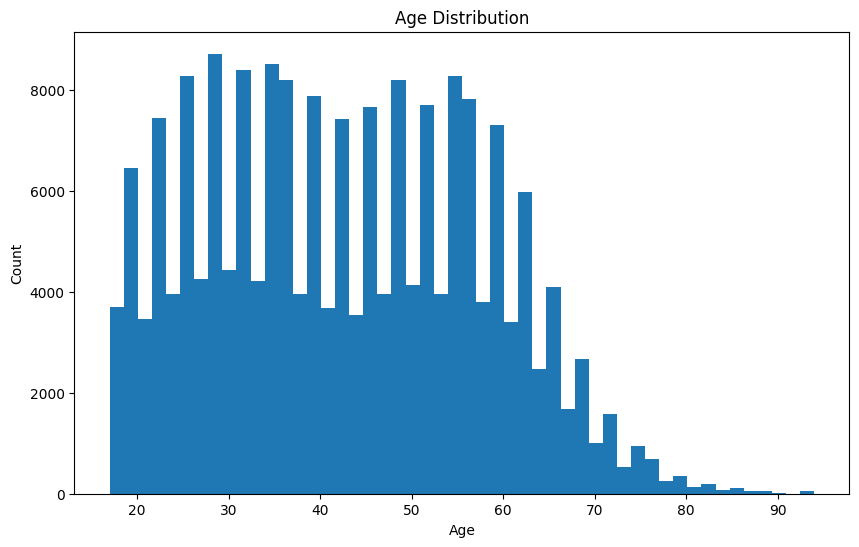

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df['AGEP'], bins=50)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [19]:
numerical_cols = ['AGEP', 'WKHP', 'income']
print("\nSummary statistics for numerical variables:")
print(df[numerical_cols].describe())


Summary statistics for numerical variables:
                AGEP           WKHP
count  195665.000000  195665.000000
mean       42.734914      37.866665
std        14.884622      13.019047
min        17.000000       1.000000
25%        30.000000      32.000000
50%        42.000000      40.000000
75%        55.000000      40.000000
max        94.000000      99.000000


In [20]:
categorical_cols = ['COW', 'SCHL', 'MAR', 'RELP', 'SEX', 'RAC1P']
for col in categorical_cols:
    print(f"\nDistribution of {col}:")
    print(df[col].value_counts().sort_index())


Distribution of COW:
COW
1.0    127815
2.0     13814
3.0     15765
4.0      8300
5.0      5056
6.0     16669
7.0      7678
8.0       568
Name: count, dtype: int64

Distribution of SCHL:
SCHL
1.0      3448
2.0        59
3.0        58
4.0       107
5.0       266
6.0       588
7.0       391
8.0       521
9.0      3259
10.0      467
11.0     1206
12.0     2234
13.0     1640
14.0     3138
15.0     4559
16.0    32897
17.0     4150
18.0    12964
19.0    32361
20.0    15703
21.0    46526
22.0    19593
23.0     5635
24.0     3895
Name: count, dtype: int64

Distribution of MAR:
MAR
1.0    102442
2.0      3293
3.0     17794
4.0      3728
5.0     68408
Name: count, dtype: int64

Distribution of RELP:
RELP
0.0     90761
1.0     43478
2.0     25741
3.0       482
4.0      1155
5.0      3530
6.0      1963
7.0      1508
8.0       297
9.0      1780
10.0     3064
11.0     1640
12.0     5703
13.0     6653
14.0       12
15.0     2619
16.0     1009
17.0     4270
Name: count, dtype: int64

Distribution of S

In [21]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
AGEP      0
COW       0
SCHL      0
MAR       0
OCCP      0
POBP      0
RELP      0
WKHP      0
SEX       0
RAC1P     0
income    0
dtype: int64


In [22]:
print("\nTarget Distribution:")
print(df['income'].value_counts(normalize=True))


Target Distribution:
income
False    0.589426
True     0.410574
Name: proportion, dtype: float64


In [23]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
           AGEP       COW      SCHL       MAR      OCCP      POBP      RELP  \
AGEP   1.000000  0.211283  0.006019 -0.483653 -0.086684  0.141928 -0.284323   
COW    0.211283  1.000000  0.076674 -0.116380 -0.086719 -0.024780 -0.062003   
SCHL   0.006019  0.076674  1.000000 -0.036824 -0.393614 -0.290688 -0.109766   
MAR   -0.483653 -0.116380 -0.036824  1.000000  0.099599 -0.175718  0.377613   
OCCP  -0.086684 -0.086719 -0.393614  0.099599  1.000000  0.107826  0.114701   
POBP   0.141928 -0.024780 -0.290688 -0.175718  0.107826  1.000000 -0.033161   
RELP  -0.284323 -0.062003 -0.109766  0.377613  0.114701 -0.033161  1.000000   
WKHP   0.074155 -0.039362  0.061382 -0.139952 -0.061002  0.040807 -0.077995   
SEX   -0.008146 -0.015855  0.064989  0.021363 -0.119644 -0.026538 -0.022385   
RAC1P -0.110367 -0.077418 -0.116413  0.035976  0.068153  0.287686  0.041970   

           WKHP       SEX     RAC1P  
AGEP   0.074155 -0.008146 -0.110367  
COW   -0.039362 -0.015855 -0.0774

In [24]:
import seaborn as sns

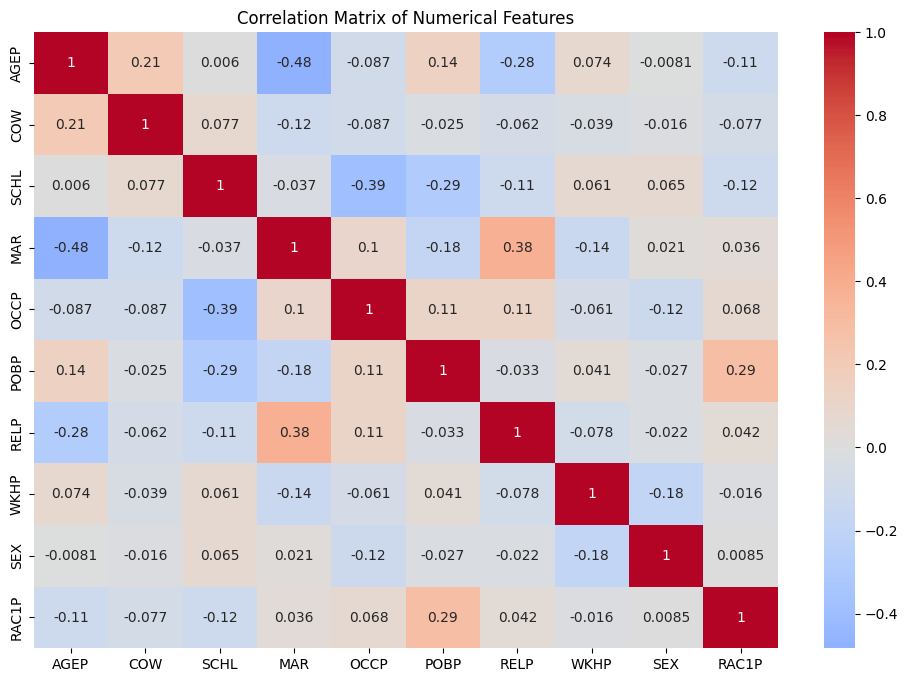

In [25]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [26]:
data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
ca_data = data_source.get_data(states=["CA"], download=True)

In [28]:
print("PINCP Statistics:")
print(ca_data['PINCP'].describe())

PINCP Statistics:
count    3.157310e+05
mean     4.760767e+04
std      7.580477e+04
min     -7.100000e+03
25%      6.740000e+03
50%      2.500000e+04
75%      6.000000e+04
max      1.325300e+06
Name: PINCP, dtype: float64


In [29]:
null_count = ca_data['PINCP'].isnull().sum()
print(f"Number of null values in PINCP: {null_count}")


Number of null values in PINCP: 63086


In [30]:
zero_count = (ca_data['PINCP'] == 0).sum()
print(f"Number of zero values in PINCP: {zero_count}")

Number of zero values in PINCP: 49099


In [31]:
negative_count = (ca_data['PINCP'] < 0).sum()
print(f"Number of negative values in PINCP: {negative_count}")

Number of negative values in PINCP: 401


In [32]:
total_records = len(ca_data['PINCP'])
print(f"\nTotal number of records: {total_records}")


Total number of records: 378817


In [33]:
print(f"\nPercentage of null values: {(null_count/total_records)*100:.2f}%")
print(f"Percentage of zero values: {(zero_count/total_records)*100:.2f}%")
print(f"Percentage of negative values: {(negative_count/total_records)*100:.2f}%")


Percentage of null values: 16.65%
Percentage of zero values: 12.96%
Percentage of negative values: 0.11%


In [2]:
data_source = ACSDataSource(survey_year='2014', horizon='1-Year', survey='person')
all_states_data = data_source.get_data(download=True)

In [ ]:
def calculate_diversity_score(state_data):
    race_dist = state_data['RAC1P'].value_counts(normalize=True)
    return 1 - np.sum(race_dist**2)

In [4]:
diversity_scores = {}
for state in all_states_data['ST'].unique():
    state_data = all_states_data[all_states_data['ST'] == state]
    diversity_scores[state] = calculate_diversity_score(state_data)

In [5]:
diversity_df = pd.DataFrame.from_dict(diversity_scores, orient='index', columns=['diversity_score'])
diversity_df.index = diversity_df.index.map(str).str.zfill(2)  # Ensure 2-digit state codes

In [8]:
import plotly.express as px

C:\Users\bsudh\AppData\Local\Temp\ipykernel_65568\4055409289.py:37: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



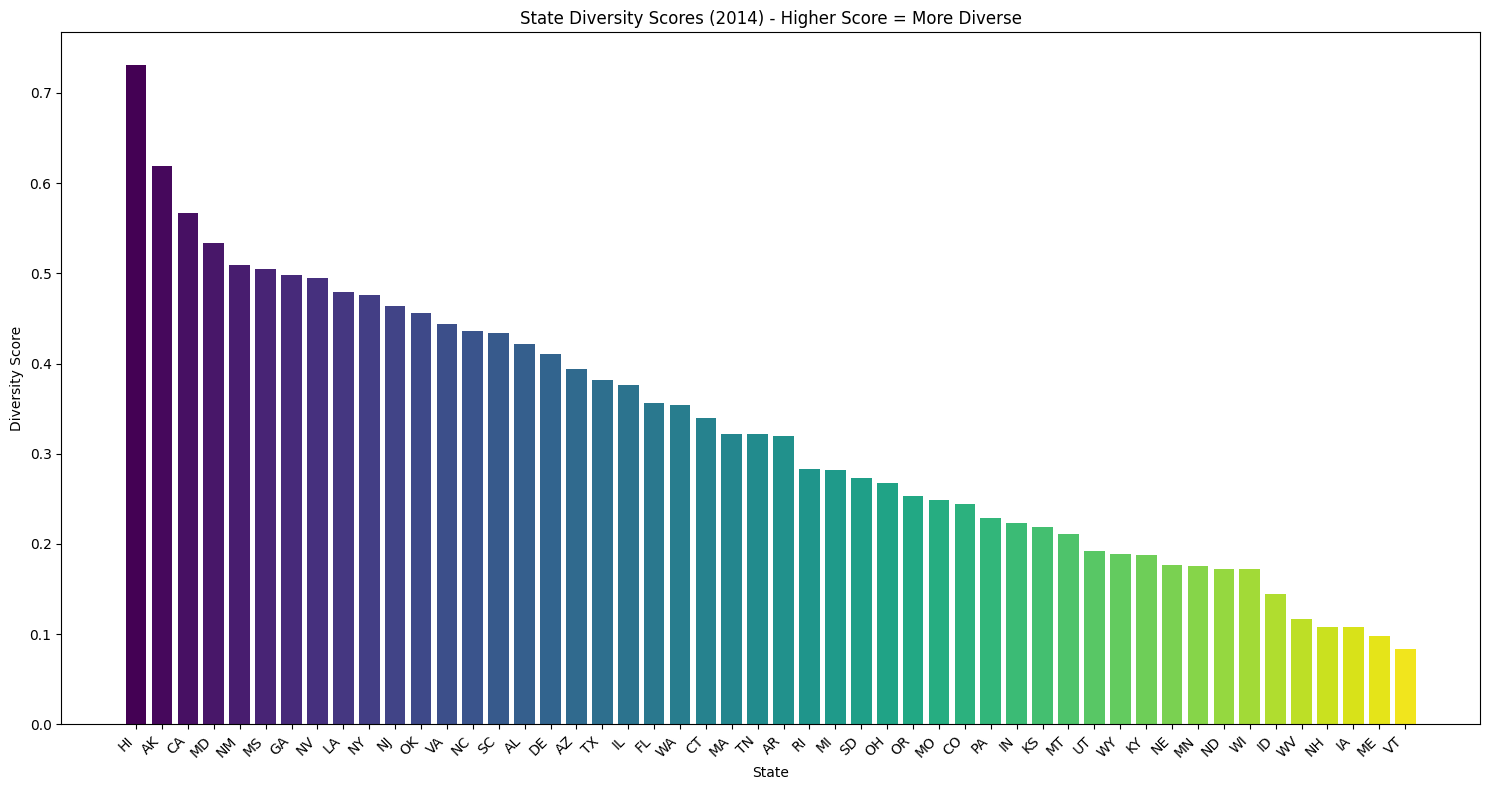


Top 5 Most Diverse States:
    Diversity Score
HI            0.731
AK            0.619
CA            0.567
MD            0.534
NM            0.509

Least 5 Diverse States:
    Diversity Score
WV            0.117
NH            0.108
IA            0.107
ME            0.098
VT            0.084


In [ ]:
diversity_scores = {}
state_names = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE', 
    11: 'DC', 12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN', 
    19: 'IA', 20: 'KS', 21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA', 
    26: 'MI', 27: 'MN', 28: 'MS', 29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV', 
    33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY', 37: 'NC', 38: 'ND', 39: 'OH', 
    40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC', 46: 'SD', 47: 'TN', 
    48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV', 55: 'WI', 
    56: 'WY'
}

In [ ]:
for state_code in all_states_data['ST'].unique():
    state_data = all_states_data[all_states_data['ST'] == state_code]
    if state_code in state_names:
        state_name = state_names[state_code]
        diversity_scores[state_name] = calculate_diversity_score(state_data)

In [ ]:
diversity_df = pd.DataFrame.from_dict(diversity_scores, orient='index', columns=['Diversity Score'])
diversity_df = diversity_df.sort_values('Diversity Score', ascending=False)

In [ ]:
plt.figure(figsize=(15, 8))
bars = plt.bar(range(len(diversity_df)), diversity_df['Diversity Score'])
plt.xticks(range(len(diversity_df)), diversity_df.index, rotation=45, ha='right')
plt.title('State Diversity Scores (2014) - Higher Score = More Diverse')
plt.xlabel('State')
plt.ylabel('Diversity Score')

cm = plt.cm.get_cmap('viridis')
for i, bar in enumerate(bars):
    bar.set_facecolor(cm(i/len(bars)))

plt.tight_layout()
plt.show()



In [ ]:
print("\nTop 5 Most Diverse States:")
print(diversity_df.head().round(3))
print("\nLeast 5 Diverse States:")
print(diversity_df.tail().round(3))

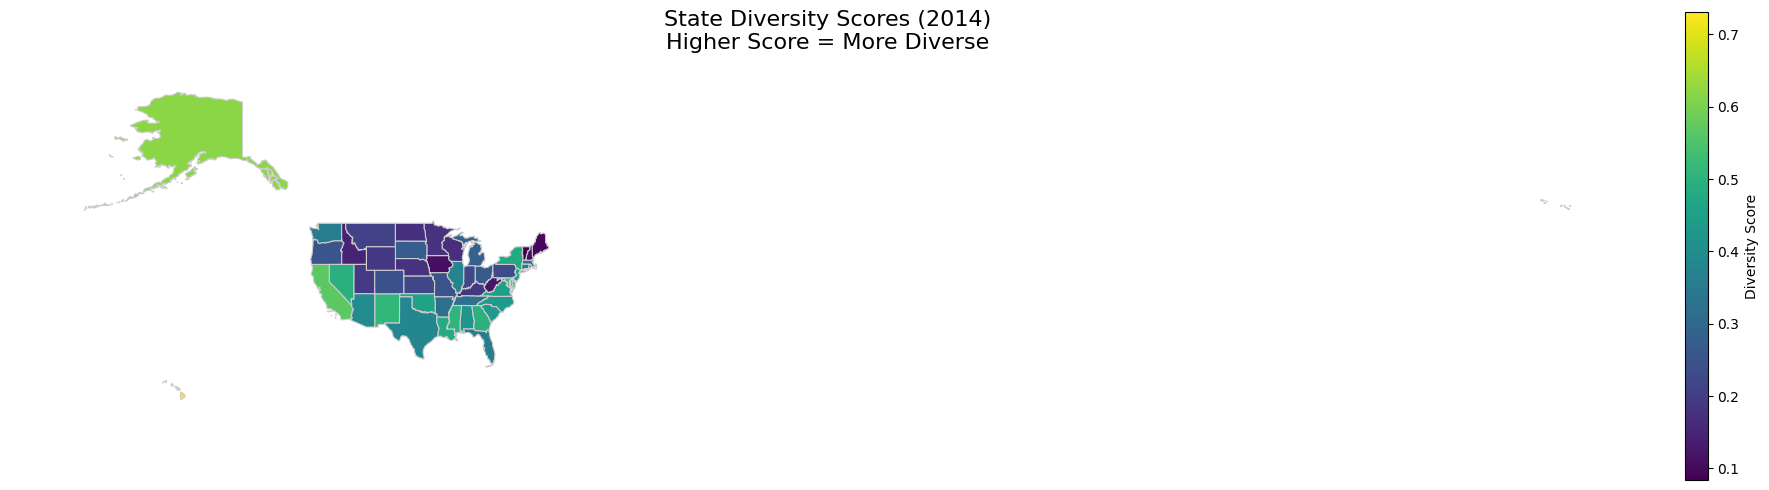


Top 5 Most Diverse States:
    diversity_score
HI            0.731
AK            0.619
CA            0.567
MD            0.534
NM            0.509

Least 5 Diverse States:
    diversity_score
WV            0.117
NH            0.108
IA            0.107
ME            0.098
VT            0.084


In [ ]:
url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip"
zip_path = "states.zip"
urlretrieve(url, zip_path)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("states_shapefile")

In [ ]:
states = gpd.read_file("states_shapefile/cb_2018_us_state_20m.shp")

In [ ]:
data_source = ACSDataSource(survey_year='2014', horizon='1-Year', survey='person')
all_states_data = data_source.get_data(download=True)

In [ ]:
diversity_scores = {}
state_fips = {
    '01': 'AL', '02': 'AK', '04': 'AZ', '05': 'AR', '06': 'CA', '08': 'CO', 
    '09': 'CT', '10': 'DE', '11': 'DC', '12': 'FL', '13': 'GA', '15': 'HI', 
    '16': 'ID', '17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', 
    '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', 
    '28': 'MS', '29': 'MO', '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', 
    '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH', 
    '40': 'OK', '41': 'OR', '42': 'PA', '44': 'RI', '45': 'SC', '46': 'SD', 
    '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', 
    '54': 'WV', '55': 'WI', '56': 'WY'
}

In [ ]:
for state_code in all_states_data['ST'].unique():
    state_data = all_states_data[all_states_data['ST'] == state_code]
    state_code_str = str(state_code).zfill(2)
    if state_code_str in state_fips:
        diversity_scores[state_fips[state_code_str]] = calculate_diversity_score(state_data)

In [ ]:
diversity_df = pd.DataFrame.from_dict(diversity_scores, orient='index', columns=['diversity_score'])

In [ ]:
states['state_abbrev'] = states['STUSPS']
merged = states.merge(diversity_df, left_on='state_abbrev', right_index=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(20, 12))
merged.plot(column='diversity_score', 
           cmap='viridis',
           linewidth=0.8,
           edgecolor='0.8',
           ax=ax,
           legend=True,
           legend_kwds={
               'label': 'Diversity Score',
               'orientation': 'vertical',
               'shrink': 0.4,
               'aspect': 20,
               'pad': 0.02
           })

ax.axis('off')

plt.title('State Diversity Scores (2014)\nHigher Score = More Diverse', 
          fontsize=16, 
          pad=20)

plt.tight_layout()

plt.show()

In [ ]:
os.remove(zip_path)
import shutil
shutil.rmtree("states_shapefile")

In [ ]:
print("\nTop 5 Most Diverse States:")
print(diversity_df.sort_values('diversity_score', ascending=False).head().round(3))
print("\nLeast 5 Diverse States:")
print(diversity_df.sort_values('diversity_score', ascending=False).tail().round(3))